IMPORTING LIBRARIES

In [3]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


LOADING THE DATASET

In [22]:
columns = ["Sepal length", "Sepal width","Petal length","Petal width","Class_labels"]

#Load the data
df = pd.read_csv('iris.csv', names= columns)
df.head(160)


,Sepal length,Sepal width,Petal length,Petal width,Class_labels
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [5]:
df.describe()

,Sepal length,Sepal width,Petal length,Petal width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
print(df.dtypes)

Sepal length    float64
Sepal width     float64
Petal length    float64
Petal width     float64
Class_labels     object
dtype: object


VISUALIZATION OF DATASET

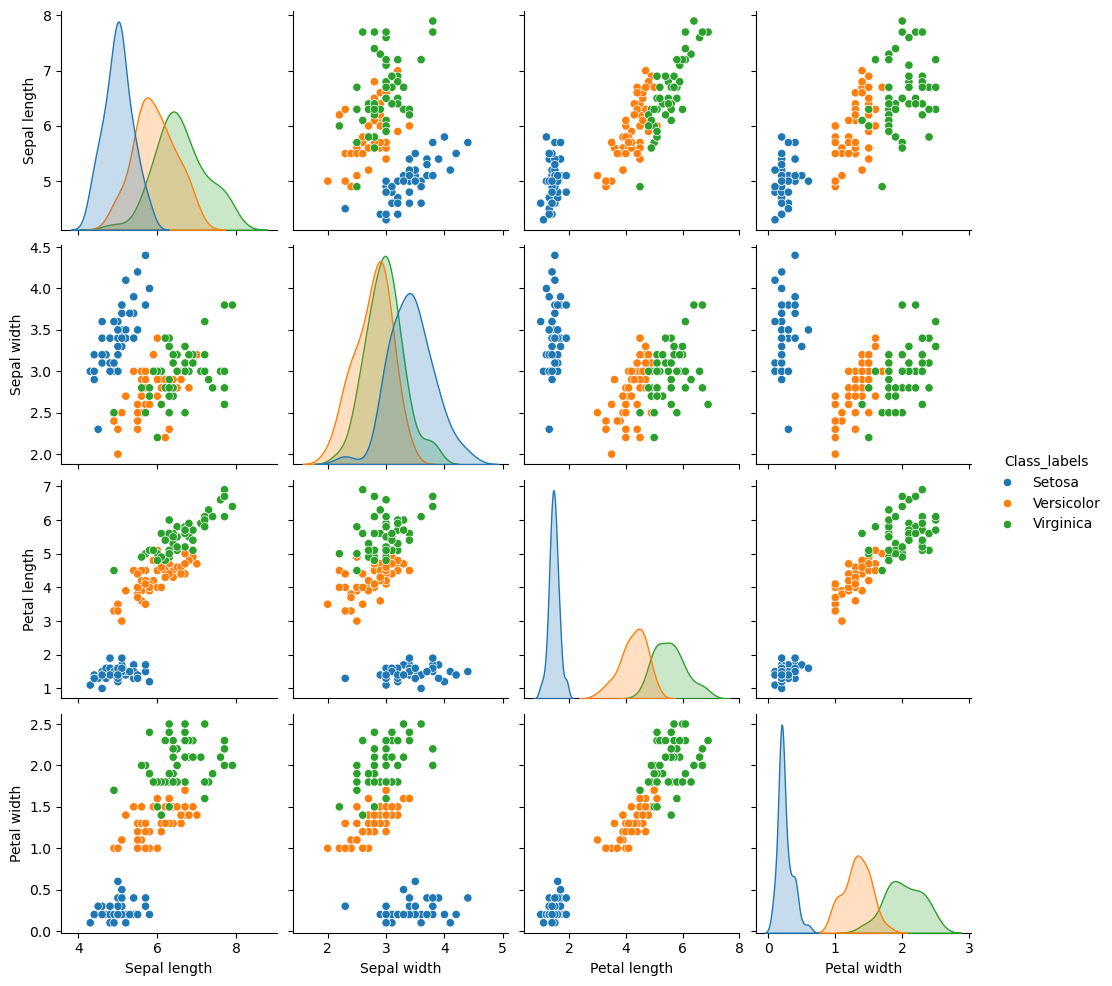

In [7]:
#Visualize the whole dataset
sns.pairplot(df, hue='Class_labels')

SEPERATING INPUT COLUMNS AND THE OUTPUT COLUMN

In [8]:
data = df.values
X = data[:,0:4]
Y = data[:,4]



SPLITTING THE DATA INTO TRAINING AND TESTING

In [9]:
#Split the data to train and test dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size = 0.2)



MODEL1: SUPPORT VECTOR MACHINE ALGORITHM

In [10]:
#SUPPORT VECTOR MACHINE ALGORITHM
from sklearn.svm import SVC
model_svc = SVC()
model_svc.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [11]:
prediction1 = model_svc.predict(X_test)
#Calculate the accuracy
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, prediction1)*100)

96.66666666666667


MODEL2: LOGISTICS REGRESSION

In [12]:
from sklearn.linear_model import LogisticRegression

model_LR = LogisticRegression(max_iter=1000)
model_LR.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
prediction2= model_LR.predict(X_test)
#calculate the accuracy
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, prediction2)*100)

96.66666666666667


MODEL 3: DECISION TREE CLASSIFIER

In [16]:
#DECISION TREE CLASSIFIER

from sklearn.tree import DecisionTreeClassifier
model_DTC=DecisionTreeClassifier()
model_DTC.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
prediction3 = model_DTC.predict(X_test)

#calculate the accuracy
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,prediction3)*100)

96.66666666666667


In [18]:
# A detailed classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, prediction2))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00         9
  Versicolor       1.00      0.89      0.94         9
   Virginica       0.92      1.00      0.96        12

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



In [19]:
X_new = np.array([[3,2,1,0.2],[4.0,2.2,3.8,1.1],[5.3,2.5,4.6,1.9]])

#predicition of the speciesfrom the input vector
prediction = model_svc.predict(X_new)
print("Prediction of Species: {}".format(prediction))


Prediction of Species: ['Setosa' 'Versicolor' 'Versicolor']
